# Quantum-feature ⟨Z⟩ ridge: presentation

This notebook presents the team's fixed Qiskit ⟨Z⟩ features with a classical ridge readout (`qridge`).
It reads the original run-1 results; it does not train, tune or select a model. The five other quantum
models are archived in `archive/quantum_models/`. Errors are in debye.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from qm9dipole import REPO_ROOT

raw = pd.read_csv(REPO_ROOT / "results/comparison/test_run01_quantum.csv")
models = ["qridge", "ridge", "rbf_krr", "rf", "mean"]
results = raw[raw["model"].isin(models)].copy()
test = results[results["eval_set"].isin(["test_familiar", "test_unseen"])].copy()
summary = test.groupby(["model", "inputs", "n_train", "eval_set"])[["mae_D", "rmse_D"]].agg(["mean", "std"])
display(summary.round(4))


/home/rd/.config/matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /tmp/matplotlib-1zs1g95r because there was an issue with the default path (/home/rd/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


mae_D          rmse_D        
                                             mean     std    mean     std
model   inputs      n_train eval_set                                     
mean    —           100     test_familiar  1.1560  0.0527  1.4829  0.0289
                            test_unseen    1.2661  0.1268  1.5343  0.1142
                    300     test_familiar  1.1422  0.0221  1.4624  0.0093
                            test_unseen    1.2597  0.0604  1.5210  0.0525
                    1000    test_familiar  1.1376  0.0114  1.4570  0.0036
                            test_unseen    1.2542  0.0320  1.5143  0.0277
qridge  pls10       100     test_familiar  0.7309  0.0723  1.0736  0.0765
                            test_unseen    0.6985  0.0503  1.0216  0.0880
                    300     test_familiar  0.5968  0.0100  0.8833  0.0469
                            test_unseen    0.5560  0.0161  0.8455  0.0495
                    1000    test_familiar  0.5454  0.0110  0.7808  0.0197
                            test_unseen    0.4931  0.0211  0.7484  0.0126
rbf_krr all_legal   100     test_familiar  0.6622  0.0401  0.9823  0.0318
                            test_unseen    0.6030  0.0436  0.9215  0.0466
                    300     test_familiar  0.5490  0.0120  0.8383  0.0262
                            test_unseen    0.4992  0.0244  0.7899  0.0241
                    1000    test_familiar  0.4527  0.0088  0.6846  0.0197
                            test_unseen    0.4199  0.0153  0.6787  0.0296
        composition 100     test_familiar  0.9828  0.0229  1.3321  0.0350
                            test_unseen    0.8650  0.0129  1.2355  0.0272
                    300     test_familiar  0.9748  0.0284  1.3134  0.0376
                            test_unseen    0.8459  0.0206  1.2008  0.0161
                    1000    test_familiar  0.9423  0.0112  1.2788  0.0200
                            test_unseen    0.8072  0.0092  1.1668  0.0118
        pls10       100     test_familiar  0.7297  0.0747  1.0550  0.0654
                            test_unseen    0.6659  0.0743  0.9877  0.0873
                    300     test_familiar  0.5784  0.0101  0.8609  0.0284
                            test_unseen    0.5203  0.0101  0.8069  0.0295
                    1000    test_familiar  0.4902  0.0085  0.7197  0.0156
                            test_unseen    0.4326  0.0096  0.6862  0.0171
rf      all_legal   100     test_familiar  0.6690  0.0250  0.9842  0.0468
                            test_unseen    0.5797  0.0221  0.8946  0.0424
                    300     test_familiar  0.5799  0.0084  0.8854  0.0054
                            test_unseen    0.4952  0.0069  0.8071  0.0095
                    1000    test_familiar  0.4886  0.0010  0.7296  0.0148
                            test_unseen    0.4125  0.0028  0.6909  0.0078
        composition 100     test_familiar  1.0148  0.0149  1.3576  0.0219
                            test_unseen    0.9205  0.0401  1.2584  0.0169
                    300     test_familiar  1.0003  0.0189  1.3379  0.0349
                            test_unseen    0.8753  0.0089  1.2239  0.0077
                    1000    test_familiar  0.9587  0.0085  1.2986  0.0155
                            test_unseen    0.8248  0.0142  1.1957  0.0140
        pls10       100     test_familiar  0.7472  0.0363  1.0795  0.0107
                            test_unseen    0.6985  0.0846  1.0277  0.0609
                    300     test_familiar  0.6324  0.0028  0.9309  0.0044
                            test_unseen    0.5943  0.0210  0.8925  0.0132
                    1000    test_familiar  0.5349  0.0130  0.7930  0.0239
                            test_unseen    0.4931  0.0269  0.7675  0.0231
ridge   all_legal   100     test_familiar  0.6659  0.0528  0.9871  0.0498
                            test_unseen    0.6085  0.0496  0.9135  0.0565
                    300     test_familiar  0.5674  0.0121  0.8595  0.0518
                            test_unseen    0.513

## Learning curves and matched baselines

N = 100 ⊂ 300 ⊂ 1,000 for seeds 0, 1, 2. The compressed baselines see the same 10 PLS inputs.
RBF on all 188 features provides a comparison before compression. Error bars show sample standard
deviation across seeds. `test_familiar` formulas occur in the training pool; the 20 formulas in
`test_familiar_q` are the ones guaranteed represented in every small training subset.


<ipython-input-1-7a943b64694c>:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


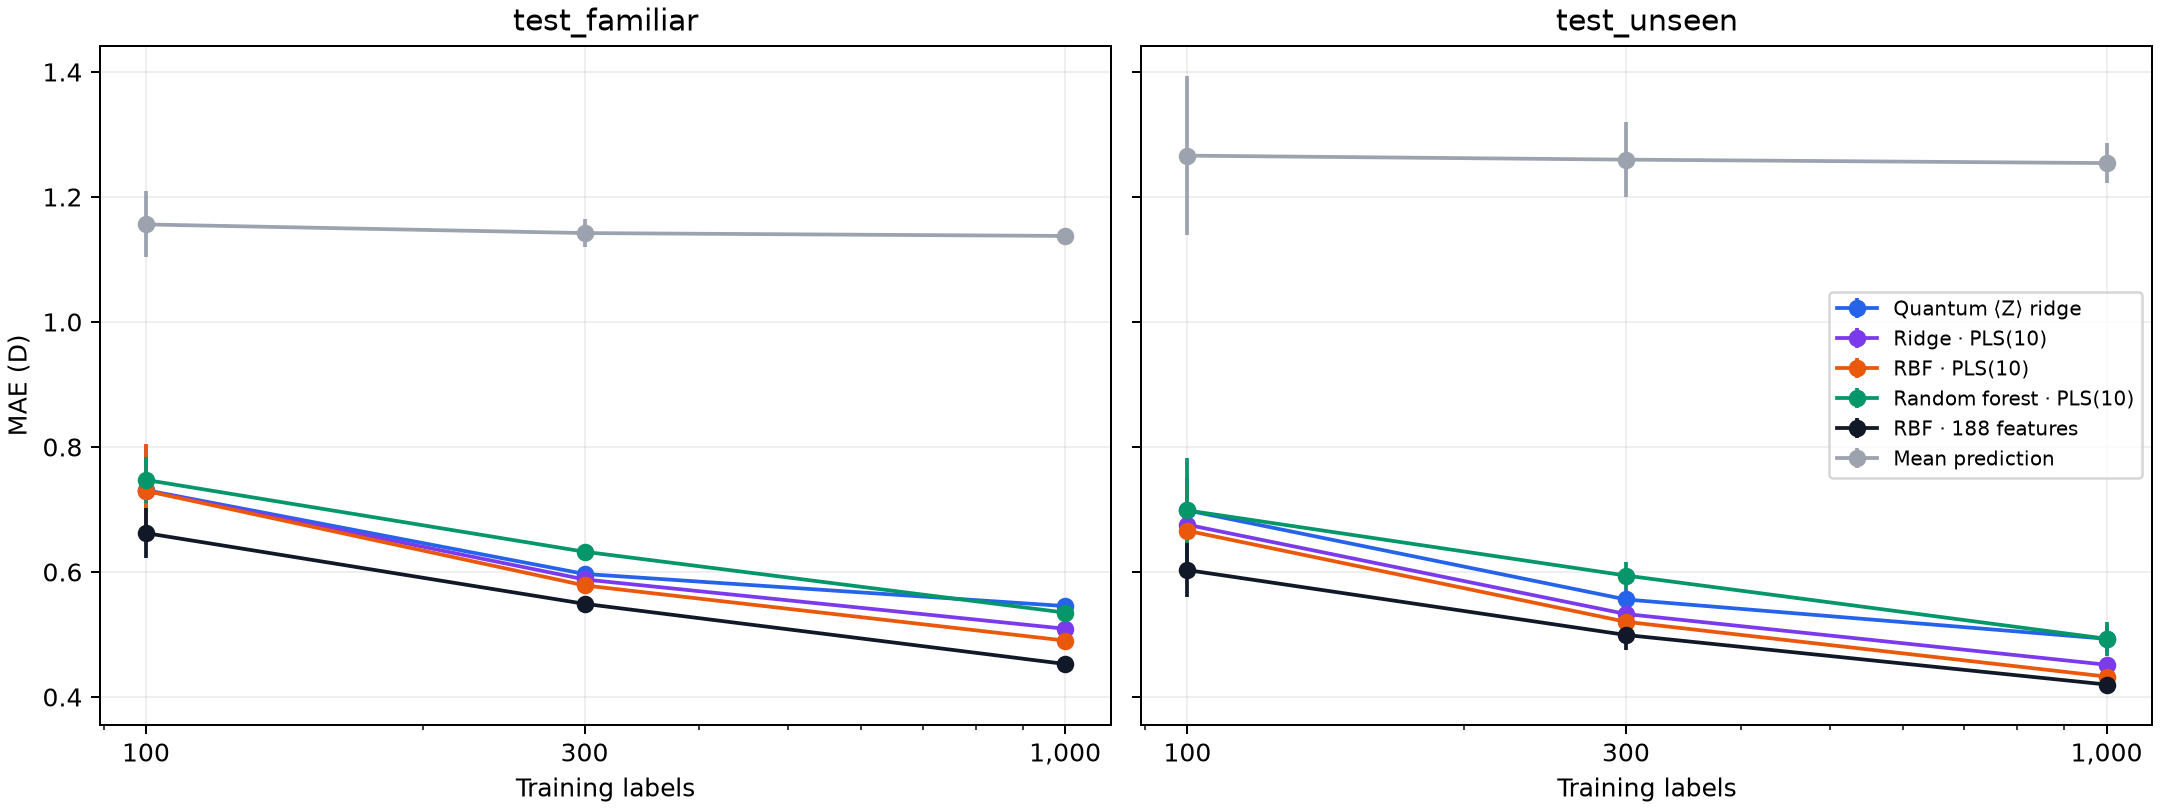

In [2]:
series = [
    ("qridge", "pls10", "Quantum ⟨Z⟩ ridge", "#2563eb"),
    ("ridge", "pls10", "Ridge · PLS(10)", "#7c3aed"),
    ("rbf_krr", "pls10", "RBF · PLS(10)", "#ea580c"),
    ("rf", "pls10", "Random forest · PLS(10)", "#059669"),
    ("rbf_krr", "all_legal", "RBF · 188 features", "#111827"),
    ("mean", "—", "Mean prediction", "#9ca3af"),
]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True, constrained_layout=True)
for ax, regime in zip(axes, ["test_familiar", "test_unseen"]):
    for model, inputs, label, color in series:
        rows = test[(test["model"] == model) & (test["inputs"] == inputs) & (test["eval_set"] == regime)]
        curve = rows.groupby("n_train")["mae_D"].agg(["mean", "std"])
        ax.errorbar(curve.index, curve["mean"], yerr=curve["std"], marker="o", label=label, color=color)
    ax.set(xscale="log", xlabel="Training labels", title=regime, xticks=[100, 300, 1000])
    ax.set_xticklabels(["100", "300", "1,000"])
    ax.grid(alpha=0.2)
axes[0].set_ylabel("MAE (D)")
axes[1].legend(fontsize=8)
output = REPO_ROOT / "figures/comparison/qridge_learning_curves.png"
output.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(output, dpi=180)
plt.show()


## Finite shots

Same molecules, N = 100, 300, 1,000; 100, 1,000 and 10,000 shots with five repetitions per seed.
The 80 familiar and 370 unseen molecules form smaller test subsets, so compare shot results against
exact results on these same subsets. The archived models' shot results are excluded below.


In [3]:
shots = pd.read_csv(REPO_ROOT / "results/hardware/test_run01_shots.csv")
shots = shots[shots["model"] == "qridge"]
display(shots.groupby(["n_train", "eval_set", "mode", "shots"])[["mae_D", "rmse_D"]].agg(["mean", "std"]).round(4))


mae_D  ...  rmse_D
                                                       mean  ...     std
n_train eval_set        mode                shots            ...        
100     test_familiar_q exact               inf      0.7891  ...  0.0743
                        features from shots 100.0    0.8694  ...  0.0679
                                            1000.0   0.8092  ...  0.0586
                                            10000.0  0.7892  ...  0.0636
        test_unseen_q   exact               inf      1.0126  ...  0.1336
                        features from shots 100.0    1.0352  ...  0.0659
                                            1000.0   1.0149  ...  0.1030
                                            10000.0  1.0130  ...  0.1108
300     test_familiar_q exact               inf      0.7216  ...  0.1596
                        features from shots 100.0    0.8361  ...  0.0751
                                            1000.0   0.7417  ...  0.1277
                                            10000.0  0.7262  ...  0.1312
        test_unseen_q   exact               inf      0.8814  ...  0.1571
                        features from shots 100.0    0.9157  ...  0.1121
                                            1000.0   0.8792  ...  0.0993
                                            10000.0  0.8830  ...  0.1341
1000    test_familiar_q exact               inf      0.6247  ...  0.0357
                        features from shots 100.0    0.7793  ...  0.0809
                                            1000.0   0.6401  ...  0.0371
                                            10000.0  0.6238  ...  0.0301
        test_unseen_q   exact               inf      0.7494  ...  0.0748
                        features from shots 100.0    0.8689  ...  0.0952
                                            1000.0   0.7702  ...  0.1056
                                            10000.0  0.7492  ...  0.0745

[24 rows x 4 columns]

## Simulated noise and IBM hardware

Training subset S_(0,100); 60 test molecules, 30 per quantum subset. The hardware run used
160 circuits × 1,000 shots on `ibm_quebec`, job `db3da0kvf2bc73csuk60`, and 45 s of charged QPU time.
This is a feasibility demonstration with one seed; the small test sample does not establish an advantage.


In [4]:
noise = pd.read_csv(REPO_ROOT / "results/hardware/test_run01_noise.csv")
display(noise[noise["model"] == "qridge"])
for name in ["hardware_FakeQuebec_20261007-2019_scores.csv", "hardware_ibm_quebec_20261007-1925_scores.csv"]:
    hardware = pd.read_csv(REPO_ROOT / "results/hardware" / name)
    display(hardware[hardware["model"] == "qridge"])


,model,mode,mae_D,rmse_D,rmse_below_tail_D,r2,bias_D,run
7,qridge,exact,0.794294,1.158221,1.158221,0.418220,-0.305349,1
8,qridge,shots only,0.817371,1.167779,1.167779,0.408578,-0.307037,1
9,qridge,noisy,0.811954,1.199853,1.199853,0.375644,-0.327418,1


,model,mode,test_subset,n_test,mae_D,rmse_D,rmse_below_tail_D,r2,bias_D
9,qridge,exact,both,60,0.794294,1.158221,1.158221,0.418220,-0.305349
10,qridge,exact,test_familiar_q,30,0.784378,1.248457,1.248457,0.499809,-0.186422
11,qridge,exact,test_unseen_q,30,0.804211,1.060333,1.060333,0.244467,-0.424276
12,qridge,"ideal device, 1,000 shots",both,60,0.815690,1.178490,1.178490,0.397680,-0.320108
13,qridge,"ideal device, 1,000 shots",test_familiar_q,30,0.808814,1.249794,1.249794,0.498737,-0.214289
14,qridge,"ideal device, 1,000 shots",test_unseen_q,30,0.822566,1.102584,1.102584,0.183057,-0.425927
15,qridge,FakeQuebec noise model (local Aer),both,60,0.798327,1.161911,1.161911,0.414508,-0.276169
16,qridge,FakeQuebec noise model (local Aer),test_familiar_q,30,0.800483,1.270010,1.270010,0.482389,-0.124536
17,qridge,FakeQuebec noise model (local Aer),test_unseen_q,30,0.796170,1.042663,1.042663,0.269438,-0.427803


,model,mode,test_subset,n_test,mae_D,rmse_D,rmse_below_tail_D,r2,bias_D
0,qridge,exact,both,60,0.794294,1.158221,1.158221,0.418220,-0.305349
1,qridge,exact,test_familiar_q,30,0.784378,1.248457,1.248457,0.499809,-0.186422
2,qridge,exact,test_unseen_q,30,0.804211,1.060333,1.060333,0.244467,-0.424276
3,qridge,"ideal device, 1,000 shots",both,60,0.805823,1.165624,1.165624,0.410759,-0.302656
4,qridge,"ideal device, 1,000 shots",test_familiar_q,30,0.821917,1.266039,1.266039,0.485621,-0.221865
5,qridge,"ideal device, 1,000 shots",test_unseen_q,30,0.789730,1.055701,1.055701,0.251055,-0.383448
6,qridge,ibm_quebec,both,60,0.777835,1.174839,1.174839,0.401406,-0.293431
7,qridge,ibm_quebec,test_familiar_q,30,0.791868,1.299644,1.299644,0.457952,-0.197442
8,qridge,ibm_quebec,test_unseen_q,30,0.763801,1.035093,1.035093,0.280008,-0.389419


## Interpretation and remaining checks

At 1,000 labels, ⟨Z⟩ ridge has familiar/unseen MAE 0.545/0.493 D, compared with 0.509/0.452 D
for plain ridge and 0.490/0.433 D for RBF on the same compressed inputs. There is no demonstrated
quantum label-efficiency advantage. At 1,000 shots on the quantum test subsets, the additional
MAE is about 0.015/0.021 D.

The shared descriptor invariance checks remain in `notebooks/02_descriptors_invariance.ipynb`.
The old end-to-end quantum invariance table and quantum composition ablation belong to archived models;
⟨Z⟩ ridge needs its own demonstrations before these can be claimed for this presentation.
